### Logistic Regression on Bank Data

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline


In [130]:
df = pd.read_csv("./Bank Customer Churn Prediction.csv")
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


<Axes: >

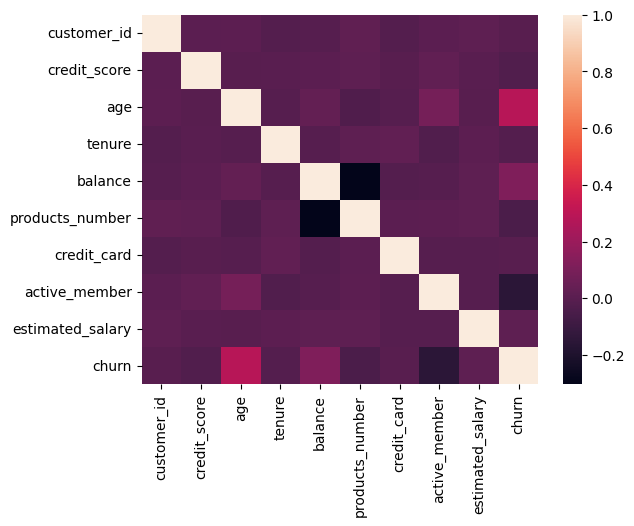

In [131]:
sns.heatmap(df.select_dtypes(include=['number']).corr())

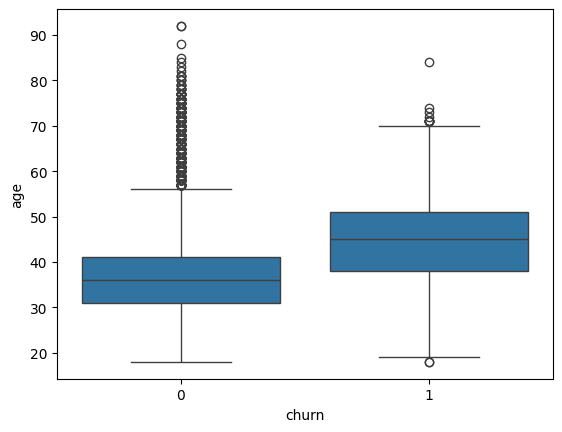

In [132]:
sns.boxplot(x = 'churn',y = 'age', data = df)
plt.show()

In [133]:
df['gender'].value_counts()

gender
Male      5457
Female    4543
Name: count, dtype: int64

In [134]:
encoder = LabelEncoder()
df['encoded_gen'] = encoder.fit_transform(df['gender'])
df[['churn','encoded_gen']].sample(5)

,churn,encoded_gen
9611,0,1
724,0,1
7723,0,1
2925,0,0
4026,1,1


In [135]:
df.head(1)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,encoded_gen
0,15634602,619,France,Female,42,2,0.0,1,1,1,101348.88,1,0


In [136]:
x = df[['age','credit_score','encoded_gen','tenure','balance','products_number','credit_card','active_member','estimated_salary']]
y= df['churn']

In [137]:
x_tr,x_ts ,y_tr,y_ts = train_test_split(x,y,test_size=0.2)
scaler = StandardScaler()
x_tr_scaled = scaler.fit_transform(x_tr)   # fit+transform train
x_ts_scaled = scaler.transform(x_ts)   # only transform test

In [138]:
model = LogisticRegression(max_iter=1000)  # increase iterations
model.fit(x_tr_scaled, y_tr)
model.score(x_ts_scaled, y_ts)

0.806

In [139]:
model.coef_

array([[ 0.77157238, -0.0622617 , -0.25545896, -0.05180081,  0.31976455,
        -0.01299358, -0.04600522, -0.54063758,  0.03513363]])

In [140]:
y_pred = model.predict(x_ts_scaled)
y_prob = model.predict_proba(x_ts_scaled)[:, 1]

In [156]:
scores = []

for lam in np.arange(0.01,100,0.1):
  pipe = make_pipeline(StandardScaler(), LogisticRegression(C=1/lam))
  pipe.fit(x_tr,y_tr)
  score = pipe.score(x_ts,y_ts)
  scores.append(score)

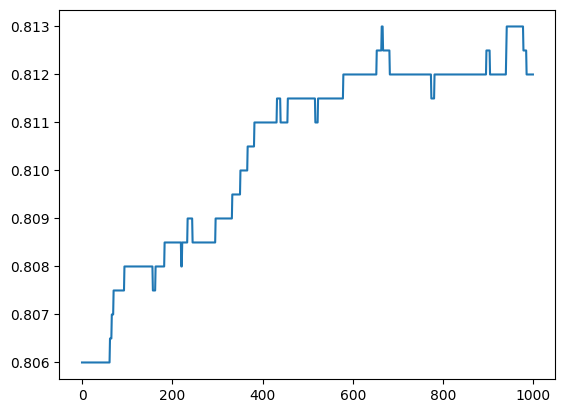

In [157]:
plt.plot(scores)

In [158]:
np.argmax(scores)

np.int64(664)

In [159]:
pipe = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=1/664)
)

pipe.fit(x_tr, y_tr)
print("Test accuracy:", pipe.score(x_ts, y_ts))

Test accuracy: 0.8055
